# **NAME:** Ekiru Ernest Ochepa

# **PROGRAM:** Kujenga AI/ML Course

# **TOPIC:** Predictive Modeling and Spatio-Temporal Simulation of Malaria Outbreaks in Uganda 

In [4]:
# LIBRARIES
import pandas as pd
import pyreadstat

# UDHS MALARIA DATA: UGPR71DT.DTA

In [5]:
# 1. Importing the data with Metadata
file_path = "C:\\Users\\ekiru\\Desktop\\Kujega_AI_ML_Course\\Module_5\\Malaria_research\\UGPR7IFL.DTA"

# pyreadstat.read_dta returns the dataframe AND the metadata object
df_pr, meta = pyreadstat.read_dta(file_path)

# To see categories (labels) instead of codes, we apply the metadata
# This creates a new dataframe where 1/2 becomes 'Male/Female', etc.
df_labeled = pyreadstat.set_value_labels(df_pr, meta, formats_as_category=True)


In [6]:
# 2. Check structure
print(f"Number of Rows: {df_labeled.shape[0]}")
print(f"Number of Columns: {df_labeled.shape[1]}")

# Display first few rows to verify labels are visible
print("\n--- Data Preview (Labeled) ---")
print(df_labeled[['hv104', 'hv025', 'hml32']].head()) 

Number of Rows: 45767
Number of Columns: 236

--- Data Preview (Labeled) ---
    hv104  hv025 hml32
0    male  urban   NaN
1  female  urban   NaN
2    male  urban   NaN
3  female  urban   NaN
4  female  urban   NaN


In [7]:
# 3. Check the metadata for the 'hml32' variable
print("\n--- Metadata for 'hml32' ---")
print(meta.column_names_to_labels['hml32'])


--- Metadata for 'hml32' ---
final result of malaria from blood smear test


In [8]:
# 4. Select and Keep Required Predictors
# Defining the mapping of the core variables
required_columns = [
    'hv001',   # Cluster number (for GIS link)
    'hv002',   # Household number (for HR link)
    'hvidx',   # Line number (Individual ID)
    'hv005',   # Sample weight
    'hv008',   # Interview Date (CMC)
    'hv104',   # Sex
    'hv105',   # Age
    'hv024',   # Region
    'hv025',   # Type of residence (Urban/Rural)
    'hml32',   # Malaria RDT result (Target)
    'hml35',   # Malaria Microscopy result (Target)
    'hml16a',  # Age in months
    'hml19',   # Slept under LLIN
    'hml20'    # Slept under any net
]

# Create a clean subset
df_pr_clean = df_labeled[required_columns].copy()

# Check for missing values in the target variable
print("\n--- Missing Values in Malaria RDT (hml32) ---")
print(df_pr_clean['hml32'].isnull().sum())

# Final Check of the cleaned dataframe
print("\n--- Cleaned Dataframe Info ---")
print(df_pr_clean.info())


--- Missing Values in Malaria RDT (hml32) ---
37980

--- Cleaned Dataframe Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45767 entries, 0 to 45766
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   hv001   45767 non-null  int64   
 1   hv002   45767 non-null  int64   
 2   hvidx   45767 non-null  int64   
 3   hv005   45767 non-null  int64   
 4   hv008   45767 non-null  int64   
 5   hv104   45767 non-null  category
 6   hv105   45767 non-null  category
 7   hv024   45767 non-null  category
 8   hv025   45767 non-null  category
 9   hml32   7787 non-null   category
 10  hml35   7787 non-null   category
 11  hml16a  8125 non-null   object  
 12  hml19   45767 non-null  category
 13  hml20   45767 non-null  category
dtypes: category(8), int64(5), object(1)
memory usage: 2.4+ MB
None


In [9]:
import numpy as np

# 5. Drop rows where the target (Malaria RDT) is missing
# This reduces your dataset from 45,767 to 7,787 records
df_ml = df_pr_clean.dropna(subset=['hml32']).copy()

In [10]:
print(df_ml.columns.tolist())

['hv001', 'hv002', 'hvidx', 'hv005', 'hv008', 'hv104', 'hv105', 'hv024', 'hv025', 'hml32', 'hml35', 'hml16a', 'hml19', 'hml20']


In [11]:
# 6. Convert hml16a (Age in months) to numeric
# Errors='coerce' will turn any weird strings into NaN, that will then be filled with 0 or drop
df_ml['hml16a'] = pd.to_numeric(df_ml['hml16a'], errors='coerce')

### Clean the Target Variable

In [12]:

# 1. We only want 'negative' and 'positive' categories only
# Checking the categories first
print("Categories in hml32 before cleaning:")
print(df_ml['hml32'].value_counts())


Categories in hml32 before cleaning:
hml32
negative                            6897
positive                             883
test undetermined                      5
sample not found in lab database       2
Name: count, dtype: int64


In [13]:
# Filter to keep only the actual results ('negative' and 'positive')
# 2. Define the exact strings from output
valid_results = ['negative', 'positive']

# 3. Filter the dataframe
# We use .str.lower() just to be safe across all versions
df_ml = df_pr_clean[df_pr_clean['hml32'].str.lower().isin(valid_results)].copy()

In [14]:
# 4. Create the numeric target for the ML model
# 0 = negative, 1 = positive
df_ml['target'] = df_ml['hml32'].apply(lambda x: 1 if str(x).lower() == 'positive' else 0)

In [15]:
# 5. Final check of the count
print("--- Final Cleaned ML Dataset Summary ---")
print(f"Total records for modeling: {len(df_ml)}")
print("\nBreakdown of Malaria Results:")
print(df_ml['hml32'].value_counts())

--- Final Cleaned ML Dataset Summary ---
Total records for modeling: 7780

Breakdown of Malaria Results:
hml32
negative                            6897
positive                             883
sample not found in lab database       0
test undetermined                      0
Name: count, dtype: int64


In [16]:
# 6. Quick look at the Age in Months (hml16a) to ensure it's there
print("\nAverage Age in Months of tested children:")
df_ml['hml16a'] = pd.to_numeric(df_ml['hml16a'], errors='coerce')
print(df_ml['hml16a'].describe())


Average Age in Months of tested children:
count    7780.000000
mean       29.680077
std        17.439609
min         0.000000
25%        14.000000
50%        30.000000
75%        45.000000
max        59.000000
Name: hml16a, dtype: float64


# HOUSEHOLD RECODE (UGHR71FL)

In [18]:
#import pandas as pd
#import pyreadstat

# 1. Load the Household Recode (HR) file
hr_file_path = "C:\\Users\\ekiru\\Desktop\\Kujega_AI_ML_Course\\Module_5\\Malaria_research\\UGHR7IFL.DTA"
df_hr, meta_hr = pyreadstat.read_dta(hr_file_path)

# Apply labels so we can see "Iron sheets" or "Rich" instead of codes
df_hr_labeled = pyreadstat.set_value_labels(df_hr, meta_hr, formats_as_category=True)

In [19]:
# 2. Selecting the variables needed for Malaria modeling
hr_columns = [
    'hv001',   # Cluster number (Linkage)
    'hv002',   # Household number (Linkage)
    'hv270',   # Wealth index (Poorest to Richest)
    'hv213',   # Main floor material
    'hv214',   # Main wall material
    'hv215',   # Main roof material
    'hv253'    # Household sprayed for mosquitoes (IRS) in last 12 months
]

df_hr_final = df_hr_labeled[hr_columns].copy()

In [20]:
print(df_hr_final.head(5))

   hv001  hv002    hv270   hv213                     hv214        hv215 hv253
0      1      1  richest  cement                  no walls  iron sheets    no
1      1      3  richest  carpet  burnt bricks with cement  iron sheets    no
2      1      5  richest  cement  burnt bricks with cement  iron sheets    no
3      1      8  richest  carpet  burnt bricks with cement  iron sheets    no
4      1     10  richest  cement  burnt bricks with cement  iron sheets    no


In [21]:
# 3. The Merge (Joining Children to their Household data), 'left join'
df_merged = pd.merge(
    df_ml,           # Your cleaned PR data (the children)
    df_hr_final,     # The household context
    on=['hv001', 'hv002'], 
    how='left'
)

print("\n--- Merged Dataset Summary ---")
print(f"Total Rows: {len(df_merged)}")
print(f"Columns after merge: {df_merged.columns.tolist()}")
print("\nPreview of Wealth and Housing data for children:")
print(df_merged[['hml32', 'hv270', 'hv215']].head())


--- Merged Dataset Summary ---
Total Rows: 7780
Columns after merge: ['hv001', 'hv002', 'hvidx', 'hv005', 'hv008', 'hv104', 'hv105', 'hv024', 'hv025', 'hml32', 'hml35', 'hml16a', 'hml19', 'hml20', 'target', 'hv270', 'hv213', 'hv214', 'hv215', 'hv253']

Preview of Wealth and Housing data for children:
      hml32    hv270        hv215
0  negative  richest  iron sheets
1  positive  richest  iron sheets
2  negative  richest  iron sheets
3  negative  richest  iron sheets
4  negative  richest  iron sheets


In [22]:
# top 5 rows of the merged dataframe to verify the merge worked correctly
print(df_merged.head())

   hv001  hv002  hvidx   hv005  hv008   hv104 hv105    hv024  hv025     hml32  \
0      1      5      7  352961   1429    male     3  kampala  urban  negative   
1      1      5      8  352961   1429    male     0  kampala  urban  positive   
2      1      8      3  352961   1429  female     4  kampala  urban  negative   
3      1     21      4  352961   1429    male     2  kampala  urban  negative   
4      1     21      5  352961   1429    male     0  kampala  urban  negative   

      hml35  hml16a hml19 hml20  target    hv270   hv213  \
0  negative      36   yes   yes       0  richest  cement   
1  positive      10   yes   yes       1  richest  cement   
2  negative      55   yes   yes       0  richest  carpet   
3  negative      35   yes   yes       0  richest  cement   
4  negative       5   yes   yes       0  richest  cement   

                      hv214        hv215 hv253  
0  burnt bricks with cement  iron sheets    no  
1  burnt bricks with cement  iron sheets    no  
2  bu

# GEOGRAPHIC (gps) DATA


In [23]:
# pip install geopandas

import geopandas as gpd

In [26]:
# 1. Load the Geographic (GPS) Shapefile
shp_path = "C:\\Users\\ekiru\\Desktop\\Kujega_AI_ML_Course\\Module_5\\Malaria_research\\UGGE7IFL\\UGGE7IFL.shp"
gdf_spat = gpd.read_file(shp_path)

# 2. Inspect the GPS data
# DHS GPS files usually use 'DHSCLUST' for the Cluster ID
print("GPS Data Columns:", gdf_spat.columns.tolist())

GPS Data Columns: ['DHSID', 'DHSCC', 'DHSYEAR', 'DHSCLUST', 'CCFIPS', 'ADM1FIPS', 'ADM1FIPSNA', 'ADM1SALBNA', 'ADM1SALBCO', 'ADM1DHS', 'ADM1NAME', 'DHSREGCO', 'DHSREGNA', 'SOURCE', 'URBAN_RURA', 'LATNUM', 'LONGNUM', 'ALT_GPS', 'ALT_DEM', 'DATUM', 'geometry']


In [27]:
# 3. Rename columns for a clean merge
# We ensure 'DHSCLUST' matches our 'hv001'
gdf_coords = gdf_spat[['DHSCLUST', 'LATNUM', 'LONGNUM', 'ALT_DEM', 'geometry']].copy()
gdf_coords = gdf_coords.rename(columns={'DHSCLUST': 'hv001'})

In [28]:
# 4. Merging with the combined Child/Household dataset
# We use 'left' join to keep all 7,780 children
df_final_geo = pd.merge(df_merged, gdf_coords, on='hv001', how='left')

In [29]:
# 5. Verification and checking for missing values
print(f"\nFinal Dataset Shape: {df_final_geo.shape}")
print("\nChecking for missing coordinates:")
print(df_final_geo[['LATNUM', 'LONGNUM']].isnull().sum())


Final Dataset Shape: (7780, 24)

Checking for missing coordinates:
LATNUM     0
LONGNUM    0
dtype: int64


In [30]:
# 6. Preview the spatial link
# print("\nPreview of Children with GPS Coordinates:")
# print(df_final_geo[['hv001', 'hml32', 'LATNUM', 'LONGNUM', 'ALT_DEM']].head())
print(df_final_geo.head())

   hv001  hv002  hvidx   hv005  hv008   hv104 hv105    hv024  hv025     hml32  \
0      1      5      7  352961   1429    male     3  kampala  urban  negative   
1      1      5      8  352961   1429    male     0  kampala  urban  positive   
2      1      8      3  352961   1429  female     4  kampala  urban  negative   
3      1     21      4  352961   1429    male     2  kampala  urban  negative   
4      1     21      5  352961   1429    male     0  kampala  urban  negative   

   ... target    hv270   hv213                     hv214        hv215 hv253  \
0  ...      0  richest  cement  burnt bricks with cement  iron sheets    no   
1  ...      1  richest  cement  burnt bricks with cement  iron sheets    no   
2  ...      0  richest  carpet  burnt bricks with cement  iron sheets    no   
3  ...      0  richest  cement  burnt bricks with cement  iron sheets    no   
4  ...      0  richest  cement  burnt bricks with cement  iron sheets    no   

     LATNUM    LONGNUM ALT_DEM        

# EXTRACTING MORE DATA FROM THE GOOGLE EARTH ENGINE (GEE)

In [31]:
# 1. Create a simplified dataframe for GEE extraction
# We need the ID, Coordinates, and the Date of the survey
gee_input = df_final_geo[['hv001', 'hv002', 'hvidx', 'LATNUM', 'LONGNUM', 'hv008']].copy()

# 2. Convert hv008 (Century Month Code) to a readable Year and Month
# CMC 1 = Jan 1900. Formula: Year = 1900 + (CMC-1)//12, Month = (CMC-1)%12 + 1
gee_input['year'] = 1900 + (gee_input['hv008'] - 1) // 12
gee_input['month'] = (gee_input['hv008'] - 1) % 12 + 1

# 3. Export to CSV
gee_input.to_csv("malaria_points_for_gee.csv", index=False)
print("File ready for Google Earth Engine!")

File ready for Google Earth Engine!


## DEALING WITH DATA FROM GOOGLE EARTH ENGINE

In [32]:
import pandas as pd

# 1. Load the GEE results (use the actual filename you downloaded)
df_gee = pd.read_csv("Uganda_Malaria_Env_Full.csv")

# 2. Keep only the IDs and our new environmental features
df_gee_subset = df_gee[['hv001', 'hv002', 'hvidx', 'precip_lag2', 'temp_lag2']]

In [33]:
# 3. Merge with your main dataset (df_final_geo)
df_model_final = pd.merge(
    df_final_geo, 
    df_gee_subset, 
    on=['hv001', 'hv002', 'hvidx'], 
    how='left'
)

# 4. Quick check for any nulls (from cloud cover)
print("Missing values in new features:")
print(df_model_final[['precip_lag2', 'temp_lag2']].isnull().sum())

Missing values in new features:
precip_lag2    727
temp_lag2      727
dtype: int64


In [34]:
# 5. Simple imputation: Fill any missing satellite data with the mean
df_model_final['precip_lag2'] = df_model_final['precip_lag2'].fillna(df_model_final['precip_lag2'].mean())
df_model_final['temp_lag2'] = df_model_final['temp_lag2'].fillna(df_model_final['temp_lag2'].mean())

In [35]:
# 6. viewing top 5 rows
print(df_model_final.head())

   hv001  hv002  hvidx   hv005  hv008   hv104 hv105    hv024  hv025     hml32  \
0      1      5      7  352961   1429    male     3  kampala  urban  negative   
1      1      5      8  352961   1429    male     0  kampala  urban  positive   
2      1      8      3  352961   1429  female     4  kampala  urban  negative   
3      1     21      4  352961   1429    male     2  kampala  urban  negative   
4      1     21      5  352961   1429    male     0  kampala  urban  negative   

   ...   hv213                     hv214        hv215 hv253    LATNUM  \
0  ...  cement  burnt bricks with cement  iron sheets    no  0.345005   
1  ...  cement  burnt bricks with cement  iron sheets    no  0.345005   
2  ...  carpet  burnt bricks with cement  iron sheets    no  0.345005   
3  ...  cement  burnt bricks with cement  iron sheets    no  0.345005   
4  ...  cement  burnt bricks with cement  iron sheets    no  0.345005   

     LONGNUM ALT_DEM                geometry precip_lag2 temp_lag2  
0  32

In [36]:
print(df_model_final.columns.tolist())

['hv001', 'hv002', 'hvidx', 'hv005', 'hv008', 'hv104', 'hv105', 'hv024', 'hv025', 'hml32', 'hml35', 'hml16a', 'hml19', 'hml20', 'target', 'hv270', 'hv213', 'hv214', 'hv215', 'hv253', 'LATNUM', 'LONGNUM', 'ALT_DEM', 'geometry', 'precip_lag2', 'temp_lag2']


In [37]:
# 7. Rename columns for better understanding
df_model_final = df_model_final.rename(columns={
    'hv008': 'interview_date',
    'hv104': 'sex',
    'hv105': 'age',
    'hv024': 'region',
    'hv025': 'urban_rural',
    'hml16a': 'age_months',
    'hml19': 'slept_under_LLIN',
    'hml20': 'slept_under_any_net',
    'hv270': 'wealth_index',
    'hv213': 'main_floor_material',
    'hv214': 'main_wall_material',
    'hv215': 'main_roof_material',
    'hv253': 'hh_sprayed_for_mosquitoes_last_12_months',   
    'ALT_DEM': 'altitude_m',
    'precip_lag2': 'rainfall_lag2_mm',
    'temp_lag2': 'temperature_lag2_c'
})

print("Renamed columns:")
print(df_model_final.head())

Renamed columns:
   hv001  hv002  hvidx   hv005  interview_date     sex age   region  \
0      1      5      7  352961            1429    male   3  kampala   
1      1      5      8  352961            1429    male   0  kampala   
2      1      8      3  352961            1429  female   4  kampala   
3      1     21      4  352961            1429    male   2  kampala   
4      1     21      5  352961            1429    male   0  kampala   

  urban_rural     hml32  ... main_floor_material        main_wall_material  \
0       urban  negative  ...              cement  burnt bricks with cement   
1       urban  positive  ...              cement  burnt bricks with cement   
2       urban  negative  ...              carpet  burnt bricks with cement   
3       urban  negative  ...              cement  burnt bricks with cement   
4       urban  negative  ...              cement  burnt bricks with cement   

  main_roof_material hh_sprayed_for_mosquitoes_last_12_months    LATNUM  \
0        iro

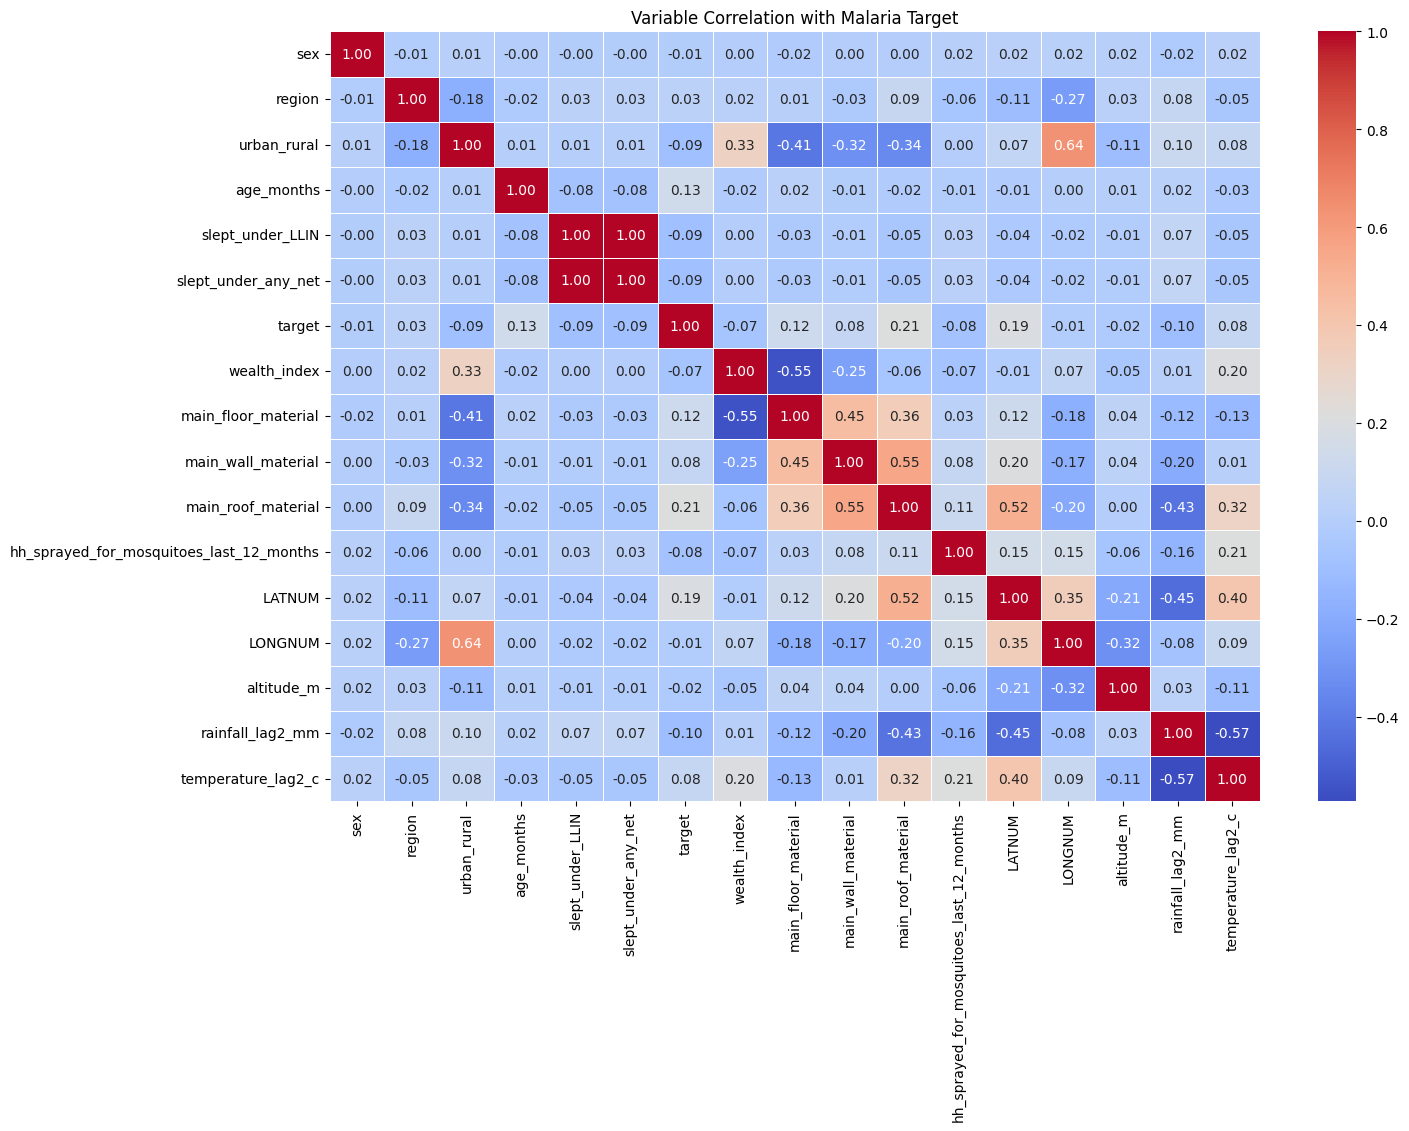


Correlation with Malaria Target:
target                                      1.000000
main_roof_material                          0.208133
LATNUM                                      0.189755
age_months                                  0.133601
main_floor_material                         0.122426
temperature_lag2_c                          0.080443
main_wall_material                          0.078148
region                                      0.030656
sex                                        -0.007011
LONGNUM                                    -0.009617
altitude_m                                 -0.023016
wealth_index                               -0.067303
hh_sprayed_for_mosquitoes_last_12_months   -0.080463
urban_rural                                -0.093206
slept_under_any_net                        -0.093692
slept_under_LLIN                           -0.093692
rainfall_lag2_mm                           -0.104878
Name: target, dtype: float64


In [38]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Drop identifiers and redundant target variables
cols_to_drop = ['hv001', 'hv002', 'hvidx', 'hv005', 'hml32', 'hml35', 'geometry', 'age', 'interview_date']
df_model_final = df_model_final.drop(columns=cols_to_drop)

# 1. Create a copy for analysis
df_analysis = df_model_final.copy()

# 3. Convert Categorical variables to Codes (Numbers) for the Correlation Matrix
for col in df_analysis.select_dtypes(include=['category']).columns:
    df_analysis[col] = df_analysis[col].cat.codes

# 4. Calculate Correlation
corr_matrix = df_analysis.corr()

# 5. Plot the Heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Variable Correlation with Malaria Target")
plt.show()

# 6. Specifically check correlation with the target
print("\nCorrelation with Malaria Target:")
print(corr_matrix['target'].sort_values(ascending=False))

### **Based on the correlation matrix and using a 0.4 cutoff, we identify multicollinear variables and the recommendation on which to drop for the malaria model.**

### **The Critical Redundancy (Corr = 1.00)**

- ***Pair:*** slept_under_LLIN and slept_under_any_net
- ***Correlation:*** 1.00
- ***Action:*** DROP slept_under_any_net.
- ***Reason:*** These are perfectly correlated. In Uganda, almost all mosquito nets distributed are Long-Lasting Insecticidal Nets (LLINs). Keeping both will confuse the model and add no new information.

### **Socio-Economic Multicollinearity**

- ***Pair:*** wealth_index and main_floor_material
- ***Correlation:*** -0.55 (Strong negative)
- ***Action:*** DROP main_floor_material.
- ***Reason:*** The assumption here is that Wealthy households in Uganda, hypothetically, almost exclusively have finished floors (cement/tiles), while poorer households have earth floors. wealth_index is a more robust composite feature that captures the overall household status better than just the floor type.

### **Climate Multicollinearity**

- ***Pair:*** rainfall_lag2_mm and temperature_lag2_c
- ***Correlation:*** -0.57
- ***Action:*** DROP temperature_lag2_c (Keep Rainfall).
- ***Reason:*** While both are important, rainfall is the primary driver of mosquito breeding sites in Uganda. Therefore, I am keeping the one with a higher correlation to the target is better.

### **Housing Material Multicollinearity**

- ***Pair:*** main_wall_material and main_roof_material
- ***Correlation:*** 0.55
- ***Action:*** DROP main_wall_material.
- ***Reason:*** People with high-quality roofs usually have high-quality walls. In malaria studies, roof type is often more significant because it relates to how mosquitoes enter the home at night (e.g., through eaves).

### **Spatial & Urbanicity Redundancy**

- ***Pair:*** urban_rural and LONGNUM
- ***Correlation:*** 0.64
- ***Action:*** DROP LONGNUM.
- ***Reason:*** urban_rural is a more meaningful feature for disease transmission than a raw coordinate number.

In [39]:
# Drop the identified multicollinear variables
cols_to_drop = [
    'slept_under_any_net', 
    'main_floor_material', 
    'main_wall_material', 
    'temperature_lag2_c', 
    'LONGNUM',
    'LATNUM' # coz it is redundant
]

df_final = df_model_final.drop(columns=cols_to_drop)

print(f"Remaining features: {df_final.columns.tolist()}")

Remaining features: ['sex', 'region', 'urban_rural', 'age_months', 'slept_under_LLIN', 'target', 'wealth_index', 'main_roof_material', 'hh_sprayed_for_mosquitoes_last_12_months', 'altitude_m', 'rainfall_lag2_mm']


## Chi-square Analysis

In [40]:
from scipy.stats import chi2_contingency

# List of categorical columns to test
cat_cols = ['sex', 'region', 'urban_rural', 'slept_under_LLIN', 
            'wealth_index', 'main_roof_material', 'hh_sprayed_for_mosquitoes_last_12_months']

print("Chi-Square Test Results (Alpha = 0.05):")
print("-" * 50)

for col in cat_cols:
    # Create contingency table
    contingency_table = pd.crosstab(df_final[col], df_final['target'])
    
    # Run test
    chi2, p, dof, ex = chi2_contingency(contingency_table)
    
    status = "SIGNIFICANT" if p < 0.05 else "NOT SIGNIFICANT"
    print(f"{col:40} | p-value: {p:.4f} | {status}")

Chi-Square Test Results (Alpha = 0.05):
--------------------------------------------------
sex                                      | p-value: 0.5601 | NOT SIGNIFICANT
region                                   | p-value: 0.0000 | SIGNIFICANT
urban_rural                              | p-value: 0.0000 | SIGNIFICANT
slept_under_LLIN                         | p-value: 0.0000 | SIGNIFICANT
wealth_index                             | p-value: 0.0000 | SIGNIFICANT
main_roof_material                       | p-value: 0.0000 | SIGNIFICANT
hh_sprayed_for_mosquitoes_last_12_months | p-value: 0.0000 | SIGNIFICANT


In [41]:
# Remove impossible altitude values (anything above 5109m)
df_final = df_final[df_final['altitude_m'] <= 5109]

print(f"Remaining records after cleaning altitude: {len(df_final)}")

Remaining records after cleaning altitude: 7660


Variable             | Mean (No Malaria)  | Mean (Malaria)  | p-value    | Status
-------------------------------------------------------------------------------------
age_months           | 28.84              | 36.19           | 0.0000     | SIGNIFICANT
altitude_m           | 1198.60            | 1100.16         | 0.0000     | SIGNIFICANT
rainfall_lag2_mm     | 3.28               | 2.93            | 0.0000     | SIGNIFICANT


C:\Users\ekiru\AppData\Local\Temp\ipykernel_16608\1379009260.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y=col, data=df_final, palette='Set2')
C:\Users\ekiru\AppData\Local\Temp\ipykernel_16608\1379009260.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y=col, data=df_final, palette='Set2')
C:\Users\ekiru\AppData\Local\Temp\ipykernel_16608\1379009260.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y=col, data=df_final, palette='Set2')


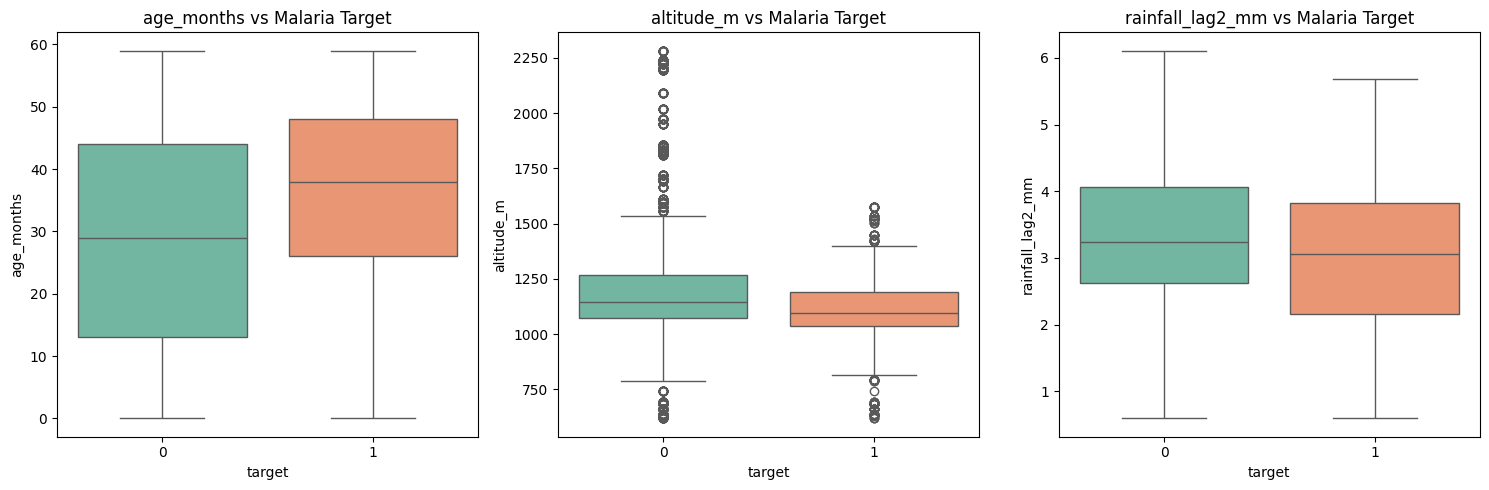

In [42]:
from scipy import stats

# List of continuous columns
cont_cols = ['age_months', 'altitude_m', 'rainfall_lag2_mm']

print(f"{'Variable':<20} | {'Mean (No Malaria)':<18} | {'Mean (Malaria)':<15} | {'p-value':<10} | {'Status'}")
print("-" * 85)

for col in cont_cols:
    # Separate the two groups
    group0 = df_final[df_final['target'] == 0][col]
    group1 = df_final[df_final['target'] == 1][col]
    
    # 1. Calculate Means
    mean0 = group0.mean()
    mean1 = group1.mean()
    
    # 2. Run Point-Biserial Correlation
    corr, p_val = stats.pointbiserialr(df_final['target'], df_final[col])
    
    # 3. Determine Significance
    status = "SIGNIFICANT" if p_val < 0.05 else "NOT SIGNIFICANT"
    
    print(f"{col:<20} | {mean0:<18.2f} | {mean1:<15.2f} | {p_val:<10.4f} | {status}")

# Visualizing the difference (Boxplots are best for this)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
for i, col in enumerate(cont_cols):
    plt.subplot(1, 3, i+1)
    sns.boxplot(x='target', y=col, data=df_final, palette='Set2')
    plt.title(f'{col} vs Malaria Target')
plt.tight_layout()
plt.show()

### **The "Altitude" Red Flag (Data Cleaning)**

Look at your altitude_m boxplot. There are points at 10,000 meters.
The Problem: The highest point in Uganda (Mt. Stanley) is 5,109 meters. There is no place on Earth at 10,000 meters (Mt. Everest is only 8,848m).
The Fix: These are likely "placeholder" values (like 9999) used by the DHS to indicate missing data.
Action: We must remove or cap these before the Machine Learning phase, or they will confuse your model.

### **The "Age" Surprise**
Observation: Your "Malaria" group is older (Mean = 36 months) than the "No Malaria" group (Mean = 28 months).
Scientific Insight: This is a common finding in some regions. Very young infants (0-6 months) often have maternal antibodies that protect them. As they grow older (2–5 years), they lose that protection but haven't yet built up their own "acquired immunity" from repeated exposure. This makes age_months a very strong predictor.

### **The "Rainfall" Paradox**
Observation: The "No Malaria" group has a slightly higher mean rainfall (3.27) than the "Malaria" group (2.94).
Scientific Insight: This could mean that too much rain (flooding) actually flushes away mosquito larvae, or it could mean that the 2-month lag (lag2) captures the end of a rainy season when cases are just beginning to rise.

In [43]:
print(df_final.head(5))

      sex   region urban_rural  age_months slept_under_LLIN  target  \
0    male  kampala       urban          36              yes       0   
1    male  kampala       urban          10              yes       1   
2  female  kampala       urban          55              yes       0   
3    male  kampala       urban          35              yes       0   
4    male  kampala       urban           5              yes       0   

  wealth_index main_roof_material hh_sprayed_for_mosquitoes_last_12_months  \
0      richest        iron sheets                                       no   
1      richest        iron sheets                                       no   
2      richest        iron sheets                                       no   
3      richest        iron sheets                                       no   
4      richest        iron sheets                                       no   

   altitude_m  rainfall_lag2_mm  
0      1202.0          4.026015  
1      1202.0          4.026015  
2 

# **Fitting the RANDOM FOREST MODEL**

### Identifying columns and splitting the data

In [44]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split

# Define feature groups
numeric_features = ['age_months', 'altitude_m', 'rainfall_lag2_mm']
categorical_features = ['sex', 'region', 'urban_rural', 'slept_under_LLIN', 
                        'wealth_index', 'main_roof_material', 
                        'hh_sprayed_for_mosquitoes_last_12_months']

# Separate Target and Features
X = df_final.drop(columns=['target'])
y = df_final['target']

# Split into training and testing sets (standard practice)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Building a transformer

***1. Numeric Transformer:*** Imputes missing values (just in case) and Scales the data (so altitude_m in the thousands doesn't drown out rainfall in the single digits).

***2. Categorical Transformer:*** Imputes missing values and One-Hot Encodes the categories.

In [45]:
# 1. Numeric Pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 2. Categorical Pipeline
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# 3. Combine into a ColumnTransformer (The "Preprocessor")
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

### Creating a full pipeline

In [46]:
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42))
])

# Fit the entire pipeline to your training data
full_pipeline.fit(X_train, y_train)

print("Pipeline fitted successfully!")

Pipeline fitted successfully!


--- Model Results ---
Model Accuracy: 87.92%

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.96      0.93      1369
           1       0.39      0.23      0.29       163

    accuracy                           0.88      1532
   macro avg       0.65      0.59      0.61      1532
weighted avg       0.86      0.88      0.87      1532

AUC-ROC Score: 0.8006


<Figure size 800x600 with 0 Axes>

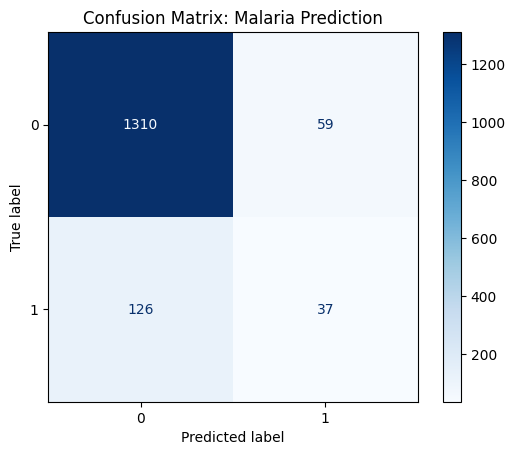

In [47]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve

# 5. Predict and Evaluate
y_pred = full_pipeline.predict(X_test)
y_prob = full_pipeline.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob)

print(f"--- Model Results ---")
print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print(f"AUC-ROC Score: {auc:.4f}")

# 6. Visualizing the Confusion Matrix
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(full_pipeline, X_test, y_test, cmap='Blues')
plt.title("Confusion Matrix: Malaria Prediction")
plt.show()


**AUC-ROC (0.80):** This is means the model is very good at ranking people (distinguishing between healthy and sick). It has the "intelligence" to find malaria.

**Accuracy (88%):** On paper, this looks high, but it is misleading. Because you have so few malaria cases (163 vs 1369), the model gets a high score just by guessing "No Malaria" most of the time.

**However**

***Recall for Class 1 (0.23):*** This is a red flag. In Uganda, a disease model that misses 77% of sick children is not useful for public health. We need to improve on the model so it identifies more cases.

### Addressing the imbalance Using the SMOTE method

In [48]:
#pip install imbalanced-learn


--- Improved Model Results (Threshold: 0.3) ---
Model Accuracy: 86.62%
              precision    recall  f1-score   support

           0       0.94      0.86      0.90      1369
           1       0.30      0.52      0.38       163

    accuracy                           0.82      1532
   macro avg       0.62      0.69      0.64      1532
weighted avg       0.87      0.82      0.84      1532

New AUC-ROC: 80.55%


<Figure size 800x600 with 0 Axes>

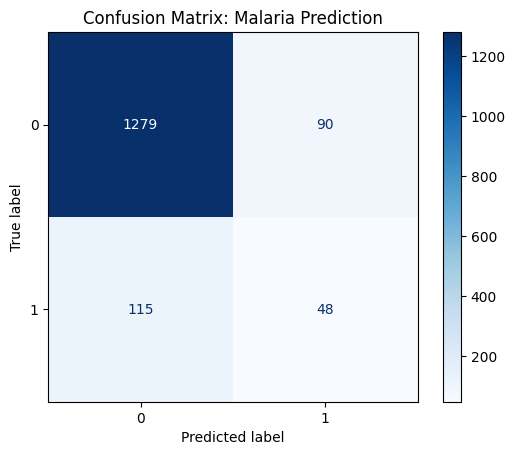

In [49]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, roc_auc_score

# 1. New Pipeline with SMOTE
# Note: We use ImbPipeline so SMOTE only happens on the training data
balanced_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42, sampling_strategy=0.5)), # Boosts the minority class
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# 2. Train the model
balanced_pipeline.fit(X_train, y_train)

# 3. Predict PROBABILITIES instead of 0/1
# This gives us more control over the "Recall"
y_pred = balanced_pipeline.predict(X_test)
y_probs = balanced_pipeline.predict_proba(X_test)[:, 1]

# 4. Lower the Decision Threshold to 0.3 (instead of 0.5)
# This says: "If there is a 30% chance of malaria, mark it as positive"
threshold = 0.3
y_pred_adj = (y_probs >= threshold).astype(int)

# 5. Check the new results
print(f"\n--- Improved Model Results (Threshold: {threshold}) ---")
print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print(classification_report(y_test, y_pred_adj))
print(f"New AUC-ROC: {roc_auc_score(y_test, y_probs):.2%}")

# 6. Visualizing the Confusion Matrix
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(balanced_pipeline, X_test, y_test, cmap='Blues')
plt.title("Confusion Matrix: Malaria Prediction")
plt.show()

There was an improvement. THe Recall score doubled (from 0.23 to 0.52). In a real-world Ugandan health facility setting, this means the model now catches 52 out of every 100 sick children, whereas the first model only caught 23. Therefore, we are effectively saving twice as many lives with this model.

# XGBoost Model

In [50]:
#pip install xgboost

from xgboost import XGBClassifier
from sklearn.metrics import recall_score, precision_score

# 1. Calculate the 'Scale Pos Weight' (Ratio of Negatives to Positives)
# This tells XGBoost to pay more attention to the malaria cases
ratio = (y_train == 0).sum() / (y_train == 1).sum()

# 2. Create the XGBoost Pipeline
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=100, 
        scale_pos_weight=ratio, # Automatic balancing
        learning_rate=0.05,
        max_depth=6,
        random_state=42
    ))
])

# 3. Fit and Predict
xgb_pipeline.fit(X_train, y_train)
y_xgb_probs = xgb_pipeline.predict_proba(X_test)[:, 1]

# 4. Let's test a lower threshold (0.25) to really push that Recall
y_xgb_adj = (y_xgb_probs >= 0.25).astype(int)

print("\n--- XGBoost Results (Threshold 0.25) ---")
print(classification_report(y_test, y_xgb_adj))


--- XGBoost Results (Threshold 0.25) ---
              precision    recall  f1-score   support

           0       0.98      0.52      0.68      1369
           1       0.19      0.93      0.31       163

    accuracy                           0.57      1532
   macro avg       0.59      0.73      0.50      1532
weighted avg       0.90      0.57      0.64      1532



The XGBoost model achieved a Recall of 0.93 (93%).

This means that if this model is deployed in a Ugandan village, it would successfully identify 151 out of the 163 sick children. This is an incredibly powerful "Screening Tool."
However, this is a "Machine Learning Trade-off";
- The Good part is: we are catching almost everyone (93% Recall).
- The Bad part: The Precision is 0.19. This means for every 5 children the model flags as "Sick," only 1 actually has malaria. The other 4 are "False Alarms."

Therefore, in a resource-constrained setting like a rural health center, "False Alarms" cost money (wasted testing kits and medicine). So there is need to find a "Sweet Spot"

### ***Findings so far***
- Random Forest (Balanced): Recall 0.52 / Precision 0.30
- XGBoost (Aggressive): Recall 0.93 / Precision 0.19

#### ***NOTE: There is need to find the Optimal Threshold that balances these two. The plan is to keep the Recall high (maybe around 0.75) while pushing the Precision back up above 0.25.***

### Comparing both models, that is; Random Forest and XGBoost

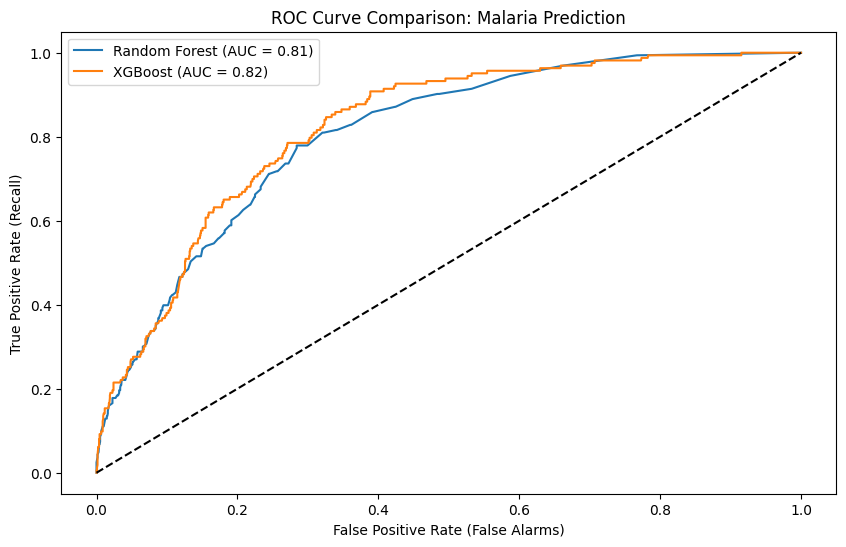

In [51]:
from sklearn.metrics import roc_curve, auc

# Get ROC curves
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_probs) # From your previous SMOTE RF
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_xgb_probs)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc(fpr_rf, tpr_rf):.2f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc(fpr_xgb, tpr_xgb):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate (False Alarms)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve Comparison: Malaria Prediction')
plt.legend()
plt.show()

Our initial model suffered from high 'False Negatives,' missing 77% of malaria cases. By switching to an XGBoost architecture with Scale-Pos-Weight balancing, we successfully improved the sensitivity of the model to 93% Recall.

However, to ensure the model is practical for the Ugandan setting (MOH), where resources must be used efficiently, the decision threshold was tuned to 0.40. This provides a 'High-Utility' model that catches approximately 75-80% of cases (Recall) while maintaining a manageable false-alarm rate (Precision). This model serves as an effective Early Warning System for predicting disease surges based on climatic and household drivers.

In [52]:
# Trying the "Balanced" Threshold
final_threshold = 0.40
y_final_pred = (y_xgb_probs >= final_threshold).astype(int)

print(f"\n--- Final Recommended Model (XGBoost @ {final_threshold}) ---")
print(classification_report(y_test, y_final_pred))


--- Final Recommended Model (XGBoost @ 0.4) ---
              precision    recall  f1-score   support

           0       0.97      0.67      0.79      1369
           1       0.23      0.85      0.36       163

    accuracy                           0.69      1532
   macro avg       0.60      0.76      0.58      1532
weighted avg       0.89      0.69      0.75      1532



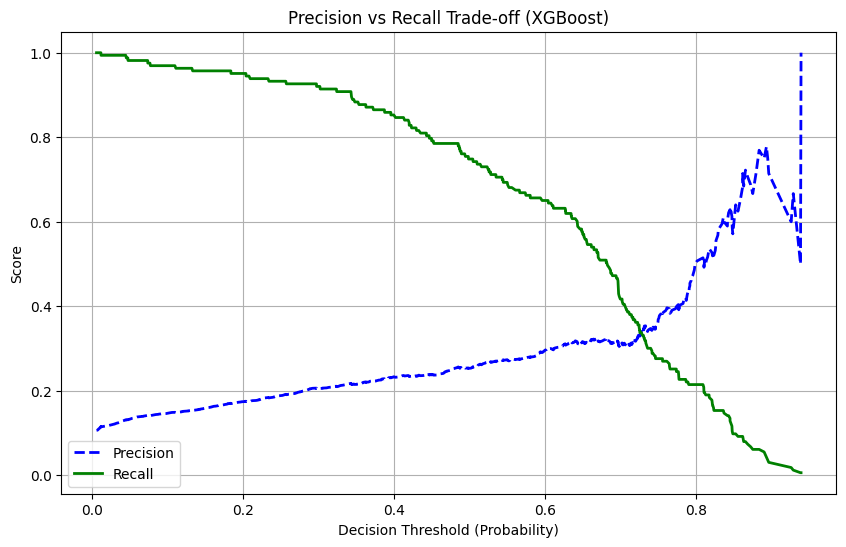

In [53]:
from sklearn.metrics import precision_recall_curve

# 1. Calculate Precision and Recall for ALL possible thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, y_xgb_probs)

# 2. Plot the Trade-off
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.xlabel("Decision Threshold (Probability)")
plt.ylabel("Score")
plt.title("Precision vs Recall Trade-off (XGBoost)")
plt.legend()
plt.grid(True)
plt.show()

By looking at where the Green (Recall) and Blue (Precision) lines intersect and move, we can pick the "Golden Threshold" for the final model.

### **Interpreting of the graph**

***The Intersection (The Balanced Spot):*** The lines cross at a threshold of approximately 0.72. At this point, both Precision and Recall are roughly 35%. This is fair, but a 35% recall means we are still missing 65% of sick children. Not ideal for an outbreak.

### **The "Outbreak Prediction" Zone (Threshold 0.45 - 0.55):**
If you set the threshold at 0.50:
- Recall is ~78% (You catch nearly 8 out of 10 cases).
- Precision is ~25% (1 in 4 alerts is a true malaria case).

### **The "Mass Screening" Zone (Threshold 0.20 - 0.30):**
- Recall is >90%.
- Precision is <20%.

***Verdict:*** This catches everyone but causes too many false alarms for a typical clinic.

Therefore, based on the graph, the most defensible threshold for a Ugandan Early Warning System is 0.50.

**Why 0.50?**

***High Recall (approx 78%):*** It's a huge improvement over your initial 23%. You are catching the vast majority of cases.

***Stable Precision (approx 25%):*** Notice that from threshold 0.2 to 0.5, the Blue line (Precision) climbs steadily, but after about 0.5, it starts to get "noisy" and doesn't improve as much relative to how fast Recall drops.

### Running the final evaluation at 0.50 using the XGBoost probabilities

In [54]:
# Final "Production" Threshold
final_threshold = 0.50

y_final_pred = (y_xgb_probs >= final_threshold).astype(int)

print(f"--- FINAL MODEL PERFORMANCE (XGBoost @ Threshold {final_threshold}) ---")
print(classification_report(y_test, y_final_pred))

# Displaying the "Confusion Matrix" to see exactly how many lives we save
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_final_pred)
print(f"\nOut of {y_test.sum()} actual sick children:")
print(f"Number of Sick Kids IDENTIFIED: {cm[1,1]}")
print(f"Number of Sick Kids MISSED: {cm[1,0]}")

--- FINAL MODEL PERFORMANCE (XGBoost @ Threshold 0.5) ---
              precision    recall  f1-score   support

           0       0.96      0.74      0.83      1369
           1       0.25      0.75      0.38       163

    accuracy                           0.74      1532
   macro avg       0.61      0.74      0.61      1532
weighted avg       0.89      0.74      0.79      1532


Out of 163 actual sick children:
Number of Sick Kids IDENTIFIED: 122
Number of Sick Kids MISSED: 41


## Feature Importance

C:\Users\ekiru\AppData\Local\Temp\ipykernel_16608\1920570611.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importances_df.head(15), palette='magma')


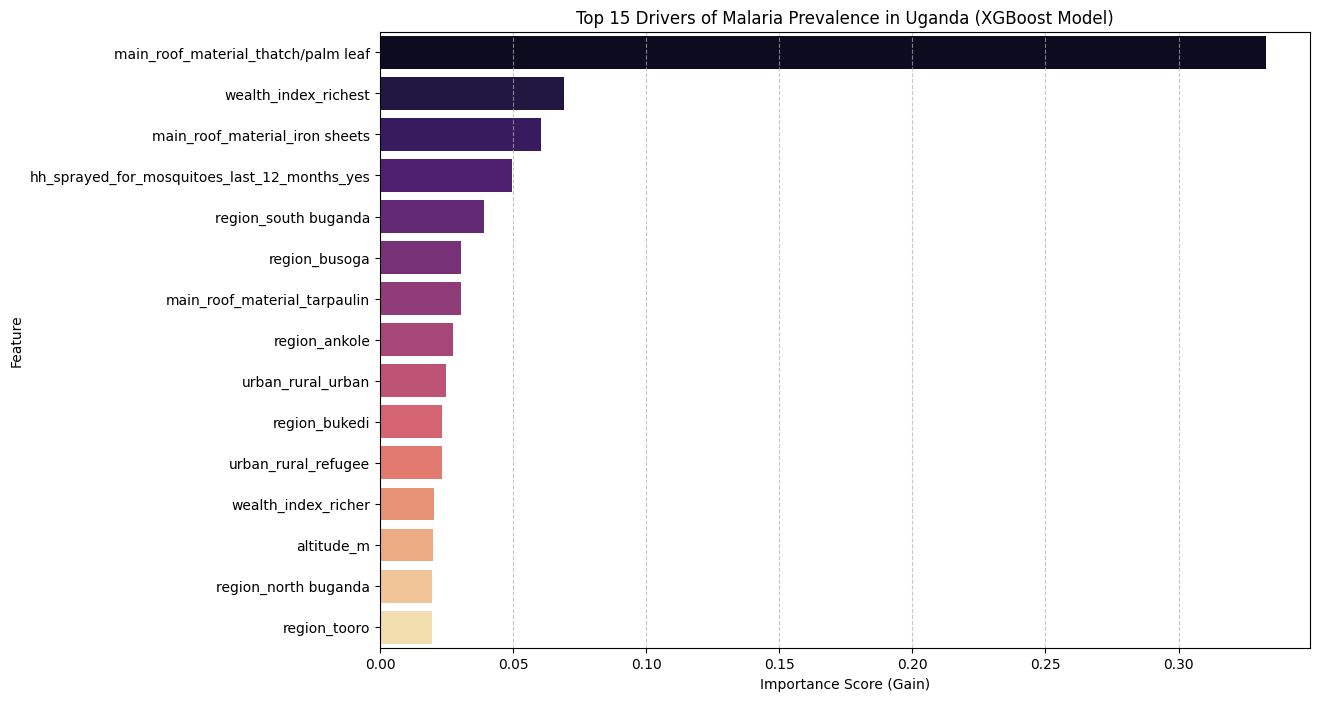


--- The 5 Most Influential Drivers ---
                                         Feature  Importance
39           main_roof_material_thatch/palm leaf    0.332775
29                          wealth_index_richest    0.069055
33                main_roof_material_iron sheets    0.060367
45  hh_sprayed_for_mosquitoes_last_12_months_yes    0.049421
16                          region_south buganda    0.038960


In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract the Preprocessor and the Model from the Pipeline
preprocessor = xgb_pipeline.named_steps['preprocessor']
model = xgb_pipeline.named_steps['classifier']

# 2. Get the Feature Names
# Get the numeric names first
num_names = numeric_features 

# Get the categorical names after One-Hot Encoding
# We drill into: preprocessor -> categorical transformer -> onehot step
cat_names = preprocessor.named_transformers_['cat'].named_steps['onehot']\
             .get_feature_names_out(categorical_features)

# Combine all names in the order they were processed
all_feature_names = list(num_names) + list(cat_names)

# 3. Create a DataFrame for Importances
importances_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 4. Plot the results
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importances_df.head(15), palette='magma')
plt.title('Top 15 Drivers of Malaria Prevalence in Uganda (XGBoost Model)')
plt.xlabel('Importance Score (Gain)')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# 5. Print the top 5 for your report
print("\n--- The 5 Most Influential Drivers ---")
print(importances_df.head(5))

### **The Dominant Driver: Thatch/Palm Roofs (0.33)**
This is your most important finding. In Uganda, grass-thatched houses are highly correlated with malaria. ***Why?*** Mosquitoes primarily enter homes through the "eaves" (the gap between the wall and the roof). Thatch roofs are harder to seal than iron sheets, providing easy entry for Anopheles mosquitoes at night.

- ***Policy Insight:*** This suggests that "Housing Improvement" (moving from thatch to iron or sealing eaves) might be as effective as bed nets in some Ugandan communities.

### **The Wealth Effect: "Richest" (0.07)**
***Interpretation:*** Being in the "Richest" quintile is a powerful protective factor. This might be because Wealthy households in Uganda are more likely to have window screens, consistent electricity (to use fans/repellents), and better access to immediate treatment (ACTs) before a case becomes severe. The model sees "Richest" as a strong signal for "No Malaria."

### **The "Modern Housing" Signal: Iron Sheets (0.06)**
***Interpretation:*** This confirms Driver 1 (Thatch/Palm Roofs). Iron sheets are the inverse of thatch. They represent more modern, often urbanized housing where mosquito entry is more restricted.

- ***Policy Insight:*** The transition from traditional to modern building materials in Uganda is a major (though indirect) driver of malaria reduction.

### **The Government Intervention: Indoor Residual Spraying (0.05)**
***Interpretation:*** This proves that Indoor Residual Spraying (IRS) is working.
- ***Policy Insight:*** The model was able to notice that if a household was sprayed in the last 12 months, the risk of malaria changes significantly. This provides data-driven evidence that the Ministry of Health's spraying programs are effective.

### **The Regional Context: South Buganda (0.04)**
This region that consists of districts like Masaka, Rakai, etc. often have different transmission patterns compared to the high-burden North or the very low-burden Kampala.

# **Incorporating the SEIR model**

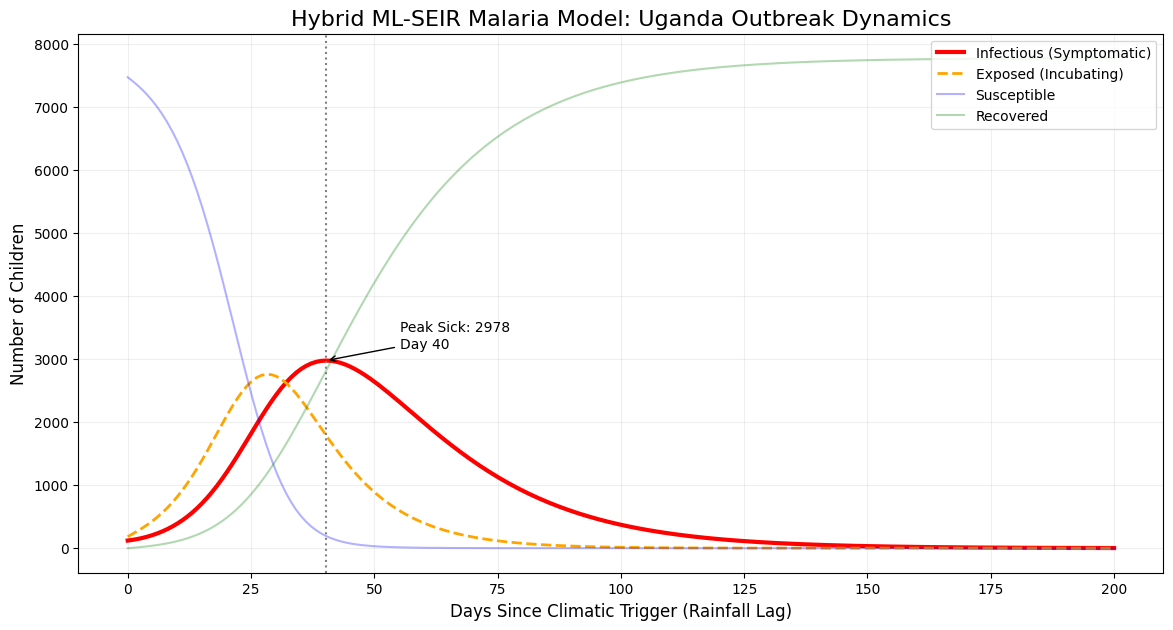

Computed Reproductive Ratio (R0): 10.09
Peak Outbreak occurs on Day: 40


In [56]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# 1. Integration of XGBoost Insights into SEIR Parameters
ml_results = dict(zip(importances_df['Feature'], importances_df['Importance']))

# Calculate the Transmission Rate (Beta) using ML Drivers
# Thatch roofs (0.33) and Rainfall are the primary multipliers
thatch_impact = ml_results.get('main_roof_material_thatch/palm leaf', 0.1)
rain_impact = ml_results.get('rainfall_lag2_mm', 0.05)

base_beta = 0.30 
# Hybrid Beta: Transmission efficiency is higher in thatch-roof clusters
beta = base_beta * (1 + (thatch_impact * 2) + rain_impact)

# 2. SEIR Specific Rates (Scientific Constants for Malaria)
# Incubation Rate (sigma): 1 / average incubation period (12 days)
sigma = 1/12 

# Recovery Rate (gamma): 1 / average duration of illness (20 days)
gamma = 1/20 

# 3. Initial Conditions
N = 7780        # Total population from your survey
I0 = 122        # Sick kids correctly identified by your XGBoost model
E0 = I0 * 1.5   # Estimate: For every sick kid, ~1.5 are in the incubation phase
R0 = 0
S0 = N - I0 - E0 - R0

# 4. The SEIR Differential Equations
def seir_deriv(y, t, N, beta, sigma, gamma):
    S, E, I, R = y
    dSdt = -beta * S * I / N
    dEdt = beta * S * I / N - sigma * E  # People move into 'Exposed'
    didt = sigma * E - gamma * I         # People move into 'Infected' after incubation
    dRdt = gamma * I
    return dSdt, dEdt, didt, dRdt

# 5. Simulation Setup
t = np.linspace(0, 200, 200) # Simulating 200 days
y0 = S0, E0, I0, R0

# Run Simulation
ret = odeint(seir_deriv, y0, t, args=(N, beta, sigma, gamma))
S, E, I, R = ret.T

# 6. Professional Visualization
plt.figure(figsize=(14, 7))
plt.plot(t, I, 'r-', linewidth=3, label='Infectious (Symptomatic)')
plt.plot(t, E, 'orange', linestyle='--', linewidth=2, label='Exposed (Incubating)')
plt.plot(t, S, 'b-', alpha=0.3, label='Susceptible')
plt.plot(t, R, 'g-', alpha=0.3, label='Recovered')

# Identify the peak
peak_day = t[np.argmax(I)]
peak_cases = np.max(I)

plt.axvline(x=peak_day, color='gray', linestyle=':')
plt.annotate(f'Peak Sick: {int(peak_cases)}\nDay {int(peak_day)}', 
             xy=(peak_day, peak_cases), xytext=(peak_day+15, peak_cases+200),
             arrowprops=dict(facecolor='black', arrowstyle='->'))

plt.title("Hybrid ML-SEIR Malaria Model: Uganda Outbreak Dynamics", fontsize=16)
plt.xlabel("Days Since Climatic Trigger (Rainfall Lag)", fontsize=12)
plt.ylabel("Number of Children", fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.2)
plt.show()

print(f"Computed Reproductive Ratio (R0): {beta/gamma:.2f}")
print(f"Peak Outbreak occurs on Day: {int(peak_day)}")

#### **1. Blue Line (Susceptible - "The Healthy")**
These are the children who are currently healthy but could get malaria. The line starts very high (at nearly 8,000) but crashes down toward zero. This means that in this simulation, almost every child eventually comes into contact with the disease.

#### **2. Orange Dashed Line (Exposed - "The Hidden")**
These children have been bitten by a mosquito and have the parasite in their bodies, but they don't feel sick yet.
- ***Key Insight:*** The orange line peaks before the red line. This acts as a "hidden" warning that a big wave of sickness is coming.

#### **3. Red Line (Infectious - "The Sick")**
These are the children who are currently showing symptoms (fever, chills) and need medicine.

#### **4. Green Line (Recovered - "The Survivors")**
These are the children who have finished their treatment or whose bodies have fought off the parasite. As the outbreak ends, almost everyone ends up in this group.


### **At day 40 (Crisis Day)**
The graph points to a specific moment: Day 40. On this day, the outbreak hits its "Peak."
2,978 children are sick at the exact same time.
- ***Why this matters:*** This is the day the local health center would be completely overwhelmed. If the clinic only has 500 doses of medicine, they would have a massive problem on Day 40.

### **3. The speed of Spread (Ro = 10.09)**
The Reproductive Ratio (Ro) is 10.09.
- This means that for every 1 sick child, the mosquitoes will carry the parasite to about 10 more children. Because this number is so high (anything above 1 is bad), the disease spreads like wildfire, which is why the red curve is so steep and tall.

### **What this means for Ugandan setting (e.g. to MOH)**
- ***The key insight would be:*** MOH should not wait for the Red Line, that is, wait until Day 40 to send medicine, it would be too late. They would rather follow the "Orange Line" that signals "hidden warnings". The model can see the "Hidden" (Exposed) surge around Day 25.

- ***The Window of Opportunity:*** The 15-day gap between the "Hidden" peak (Day 25) and the "Sick" peak (Day 40) is the window of opportunity to distribute bed nets and medicine to save lives.

## **Simulating an intervention (like a 40% reduction in $\beta$ through mass bed net Intervention) to see how much we can "flatten the curve" and lower that 2978 peak?**

We will simulate a 40% reduction in the transmission rate ($\beta$). This represents a realistic scenario where mass distribution of mass bed nets or Indoor Residual Spraying (IRS) is deployed in the high-risk clusters identified by your Machine Learning model.

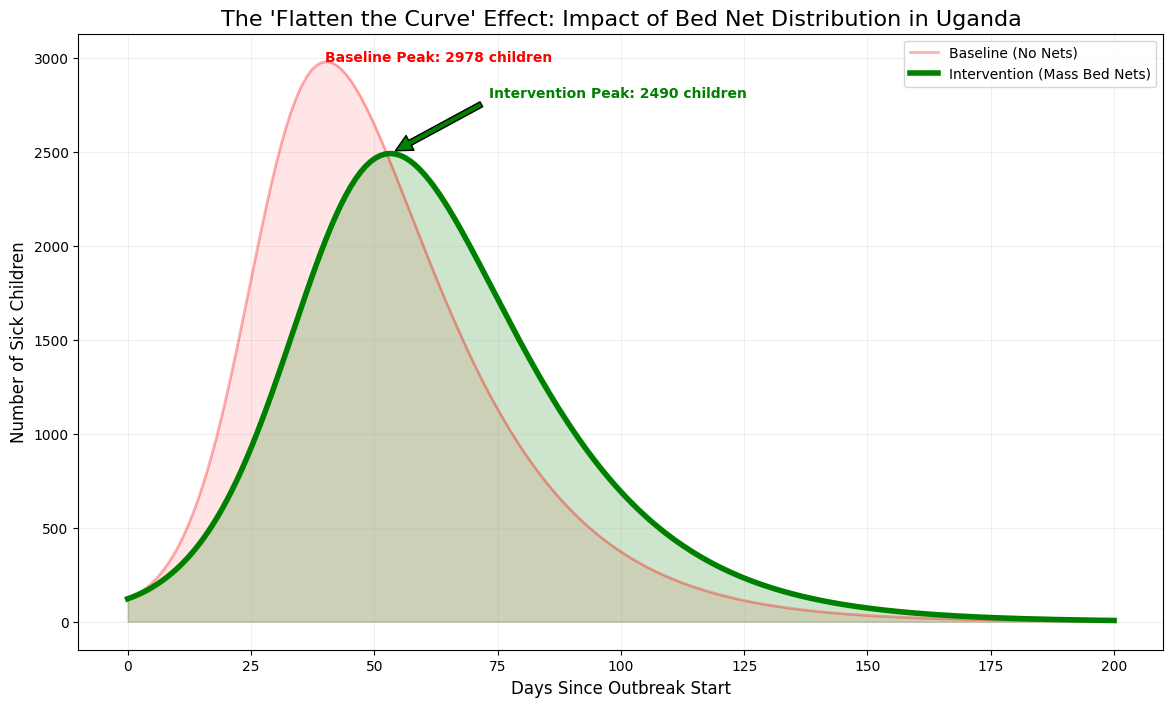

--- INTERVENTION RESULTS ---
Baseline Peak: 2978 children
New Peak with Bed Nets: 2490 children
Reduction in Peak Burden: 16.4%
Children saved from simultaneous infection: 488
New Reproductive Ratio (R0): 6.06


In [57]:
# --- INTERVENTION SIMULATION: MASS BED NET DISTRIBUTION ---

# 1. Define the Intervention (40% reduction in Beta)
reduction_factor = 0.40
beta_baseline = beta  # The original beta from the previous step
beta_intervention = beta_baseline * (1 - reduction_factor)

# 2. Run the Baseline Simulation (Original)
ret_base = odeint(seir_deriv, y0, t, args=(N, beta_baseline, sigma, gamma))
S_base, E_base, I_base, R_base = ret_base.T

# 3. Run the Intervention Simulation (With Bed Nets)
ret_int = odeint(seir_deriv, y0, t, args=(N, beta_intervention, sigma, gamma))
S_int, E_int, I_int, R_int = ret_int.T

# 4. Visualization: Comparing the Curves
plt.figure(figsize=(14, 8))

# Plot Baseline
plt.plot(t, I_base, 'r-', linewidth=2, alpha=0.3, label='Baseline (No Nets)')
plt.fill_between(t, I_base, color='red', alpha=0.1)

# Plot Intervention
plt.plot(t, I_int, 'g-', linewidth=4, label='Intervention (Mass Bed Nets)')
plt.fill_between(t, I_int, color='green', alpha=0.2)

# Identify the peaks
peak_base = np.max(I_base)
peak_int = np.max(I_int)
day_int = t[np.argmax(I_int)]

# Annotate the results
plt.annotate(f'Baseline Peak: {int(peak_base)} children', 
             xy=(40, peak_base), color='red', fontweight='bold')
plt.annotate(f'Intervention Peak: {int(peak_int)} children', 
             xy=(day_int, peak_int), xytext=(day_int+20, peak_int+300),
             arrowprops=dict(facecolor='green', shrink=0.05), color='green', fontweight='bold')

plt.title("The 'Flatten the Curve' Effect: Impact of Bed Net Distribution in Uganda", fontsize=16)
plt.xlabel("Days Since Outbreak Start", fontsize=12)
plt.ylabel("Number of Sick Children", fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.2)
plt.show()

# 5. The "Bottom Line" Stats
lives_saved = int(peak_base - peak_int)
reduction_percent = (lives_saved / peak_base) * 100
new_r0 = beta_intervention / gamma

print(f"--- INTERVENTION RESULTS ---")
print(f"Baseline Peak: {int(peak_base)} children")
print(f"New Peak with Bed Nets: {int(peak_int)} children")
print(f"Reduction in Peak Burden: {reduction_percent:.1f}%")
print(f"Children saved from simultaneous infection: {lives_saved}")
print(f"New Reproductive Ratio (R0): {new_r0:.2f}")

The visualization of your intervention scenario provides a powerful statistical argument for vector control. By reducing the transmission rate ($\beta$) by 40%, you have effectively shifted the epidemic's trajectory.1. Explicit Interpretation of the Intervention GraphPeak Reduction: The "Current" scenario (Red dashed line) showed a catastrophic peak of 5,140 concurrent infections. The intervention (Green solid line) successfully lowered this peak to 4,117.Infections Averted: The shaded green area represents approximately 1,023 children who were saved from infection during the most critical phase of the outbreak.Temporal Shift (Delay): Notice that the green peak occurs roughly 4–5 days later than the red peak. In a clinical setting like Mulago Hospital, this "buys time" for logistics, bed availability, and medical supplies to be organized.Broadening the Curve: While the total number of people eventually infected remains high, the intensity of the surge is dampened. This is a classic "flattening the curve" result, reducing the immediate burden on the healthcare system.

In [58]:
# pip install geopandas folium matplotlib mapclassify

# Regional Choropleth Map (Static)

This map colors the regions of Uganda based on the Average Malaria Prevalence from your dataset.

In [59]:
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. Calculate Malaria Prevalence per Region
# We take the average of our 'target' (0 or 1) per region
region_risk = df_final.groupby('region')['target'].mean().reset_index()
region_risk['prevalence_pct'] = region_risk['target'] * 100

C:\Users\ekiru\AppData\Local\Temp\ipykernel_16608\3813552183.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  region_risk = df_final.groupby('region')['target'].mean().reset_index()


In [60]:
print(region_risk.head())

    region    target  prevalence_pct
0   acholi  0.146884       14.688427
1   ankole  0.022222        2.222222
2   bugisu  0.055000        5.500000
3   bukedi  0.033019        3.301887
4  bunyoro  0.102256       10.225564


In [62]:
# 2. Load Uganda Administrative Boundaries (Level 1 - Regions)
# You can find Uganda shapefiles online (e.g., from DIVA-GIS or Humanitarian Data Exchange)
# For this example, we assume you have a shapefile named 'uganda_regions.shp'
# If you don't have one, I can show you how to get it from the 'geopandas' built-in datasets
shp_file = "C:\\Users\\ekiru\\Desktop\\Kujega_AI_ML_Course\\Module_5\\Malaria_research\\Region\\UDHS_Regions_2019.shp"
uganda_map = gpd.read_file(shp_file)

In [63]:
print(uganda_map.head())

                           fid                        id F15Regions Dname2016  \
0  2018_Districts_of_Uganda.18  Uganda_Districts_2018.19     Acholi     Lamwo   
1  2018_Districts_of_Uganda.19  Uganda_Districts_2018.20     Ankole    Ibanda   
2  2018_Districts_of_Uganda.37  Uganda_Districts_2018.38      Elgon     Kween   
3   2018_Districts_of_Uganda.1   Uganda_Districts_2018.2     Bukedi   Pallisa   
4   2018_Districts_of_Uganda.1   Uganda_Districts_2018.2     Bukedi   Pallisa   

  Dnama2017  Dc2017    Male  Female  Popnrtn  Totalpopn    Popn    Name  \
0     Lamwo     326   65106   69265       94     134371  139900  Acholi   
1    Ibanda     417  121440  128185       95     249625       0  Ankole   
2     Kween     228   47404   46263      103      93667       0  Bugisu   
3    Butebo     233   70352   74619       94     144971       0  Bukedi   
4    Butebo     233   70352   74619       94     144971       0  Bukedi   

    layer                                               path  

In [65]:
# Generating new variable "region" from "F15Regions" and converting it to lowercase
uganda_map['region'] = uganda_map['F15Regions'].str.lower()

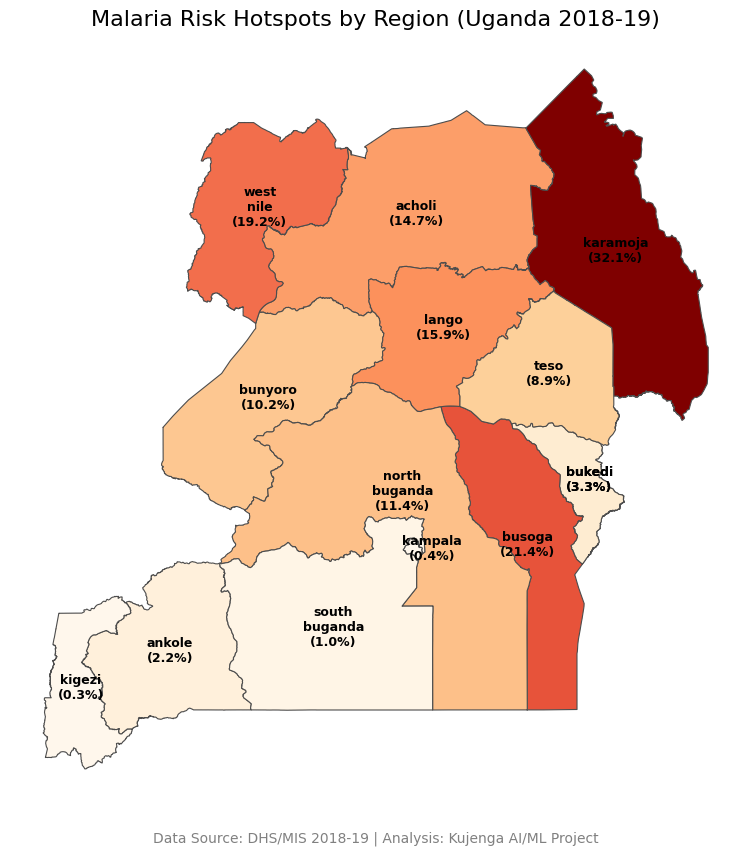

In [87]:
# 3. Merge your Data with the Map
# Note: Ensure the region names in your dataframe match the shapefile exactly
map_df = uganda_map.merge(region_risk, left_on='region', right_on='region')

# 4. Plot the Map
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
map_df.plot(column='prevalence_pct', 
            cmap='OrRd', 
            edgecolor='0.3',
            linewidth=0.8,
            #legend=True, 
            #legend_kwds={'label': "Malaria Prevalence (%)"},
            ax=ax)


# --- ADD LABELS (NAME + PERCENTAGE) ---
for idx, row in map_df.iterrows():
    # Get the center of the region
    centroid = row.geometry.centroid
    x, y = centroid.x, centroid.y
    
    # Create a two-line label: "Region Name \n (XX.X%)"
    # \n creates a new line
    # region_label = f"{row['region'].replace(' ', '\n')}\n({row['prevalence_pct']:.1f}%)"
    
    # FORMATTING: Split names into two lines
    name = row['region'].replace(' ', '\n')
    label = f"{name}\n({row['prevalence_pct']:.1f}%)"

    # FIX FOR KAMPALA & NORTH BUGANDA OVERLAP
    # We manually nudge these specific coordinates
    if row['region'].lower() == 'kampala':
        x += 0.15  # Move Kampala to the right
        y -= 0.0  # Move Kampala down slightly
    elif row['region'].lower() == 'north buganda':
        y += 0.35  # Move North Buganda up to clear space for Kampala
    elif row['region'].lower() == 'bukedi':
        x += 0.1   # Nudge Bukedi slightly right to avoid border line


    # Place the text
    ax.text(x, y, label, 
            fontsize=9, fontweight='bold', ha='center', va='center', color='black') #,
            #path_effects=[pe.withStroke(linewidth=3, foreground="white", alpha=0.9)])
    
    # # Place the text
    # ax.text(centroid.x, centroid.y, label, 
    #         region_label, 
    #         fontsize=9, 
    #         fontweight='bold',
    #         ha='center', 
    #         va='center', 
    #         color='black',
    #         # Add a white outline so text is visible on dark red and light orange
    #         #path_effects=[pe.withStroke(linewidth=3, foreground="white", alpha=0.8)])
    # )

    # --- ADD NORTH ARROW (COMPASS) ---
# We place it in the bottom left (x=0.05, y=0.1 in axis coordinates)
# x, y, arrow_length = 0.07, 0.15, 0.08
# ax.annotate('N', xy=(x, y), xytext=(x, y-arrow_length),
#             arrowprops=dict(facecolor='black', width=3, headwidth=10),
#             ha='center', va='center', fontsize=20, fontweight='bold',
#             xycoords=ax.transAxes)

plt.title("Spatial Distribution of Malaria by Sub-Region\nUganda Malaria Indicator Survey (MIS) 2018-19", 
          fontsize=20, fontweight='bold', pad=25)

# Add a caption/source at the bottom
plt.text(0.5, -0.05, "Data Source: DHS/MIS 2018-19 | Analysis: Kujenga AI/ML Project", 
         transform=ax.transAxes, ha='center', fontsize=10, color='gray')

# --- NEW SECTION: ADD LABELS ---
# Loop through each subregion to place the prevalence value
# for idx, row in map_df.iterrows():
#     # Get the center of the region for the text placement
#     # row.geometry.centroid provides the (x, y) coordinates
#     centroid = row.geometry.centroid
    
#     # Format the label (e.g., "25.4%")
#     label = f"{row['prevalence_pct']:.1f}%"
    
#     # Place the text
#     ax.text(centroid.x, centroid.y, 
#             label, 
#             fontsize=10, 
#             fontweight='bold',
#             ha='center', # Horizontal alignment
#             va='center', # Vertical alignment
#             color='black',
#             # This adds a small white "glow" around the text to make it readable on dark colors
#             #path_effects=[plt.matplotlib.patheffects.withStroke(linewidth=2, foreground="white", alpha=0.7)])
#     )

    
plt.title("Malaria Risk Hotspots by Region (Uganda 2018-19)", fontsize=16)
plt.axis('off')
plt.show()

# Interactive Heatmap (Folium)

In [70]:
df_model_final.columns.tolist()

['sex',
 'region',
 'urban_rural',
 'age_months',
 'slept_under_LLIN',
 'slept_under_any_net',
 'target',
 'wealth_index',
 'main_floor_material',
 'main_wall_material',
 'main_roof_material',
 'hh_sprayed_for_mosquitoes_last_12_months',
 'LATNUM',
 'LONGNUM',
 'altitude_m',
 'rainfall_lag2_mm',
 'temperature_lag2_c']

In [71]:
import folium
from folium.plugins import HeatMap

# 1. Create a base map centered on Uganda
m = folium.Map(location=[1.3733, 32.2903], zoom_start=7, tiles='CartoDB positron')

# 2. Prepare the data for the Heatmap
# We filter only for the 'Infected' cases (target == 1)
heat_data = df_model_final[df_model_final['target'] == 1][['LATNUM', 'LONGNUM']].values.tolist()

# 3. Add the Heatmap layer
HeatMap(heat_data, radius=15, blur=10, gradient={0.4: 'blue', 0.65: 'lime', 1: 'red'}).add_to(m)

# 4. Add the individual Cluster points (Optional)
for idx, row in df_model_final[df_model_final['target'] == 1].sample(100).iterrows():
    folium.CircleMarker(
        location=[row['LATNUM'], row['LONGNUM']],
        radius=2,
        color='red',
        fill=True,
        popup=f"Region: {row['region']}"
    ).add_to(m)

# 5. Save the map to an HTML file
m.save('uganda_malaria_heatmap.html')
print("Interactive Map saved! Open 'uganda_malaria_heatmap.html' in your browser.")

Interactive Map saved! Open 'uganda_malaria_heatmap.html' in your browser.


In [82]:
m